In [110]:
using Sunny, CairoMakie, ColorSchemes, Colors, LinearAlgebra, ProgressMeter
# Cairo for static, GL for interactive

include("/Users/fbnielsen/Library/CloudStorage/OneDrive-UniversityofCopenhagen/Uni OneDrive/4 år/Clinoatacamite/Sunny_models/func_clino1.jl")
units = Units(:meV, :angstrom)

Units(:meV, :angstrom)

# Final Q-Mag project

## Pyrochlore lattice Holmiumtitenate  $(\text{Ho}_2\text{Ti}_2\text{O}_7)$

### Definition of crystal

In [57]:
latvecs = lattice_vectors(7.175, 7.175, 7.175, 90, 90, 90) #https://legacy.materialsproject.org/materials/mp-33948/

positions = [[0.875, 0.625, 0.375],
             [0.625, 0.125, 0.625],
             [0.875, 0.875, 0.125],
             [0.625, 0.875, 0.375],
             [0.875, 0.125, 0.875],
             [0.625, 0.625, 0.125],
             [0.875, 0.375, 0.625],
             [0.625, 0.375, 0.875],
             [0.375, 0.625, 0.875],
             [0.125, 0.125, 0.125],
             [0.375, 0.875, 0.625],
             [0.125, 0.875, 0.875],
             [0.375, 0.125, 0.375],
             [0.125, 0.625, 0.625],
             [0.375, 0.375, 0.125],
             [0.125, 0.375, 0.375]
             ] # From other pyrochlore material: https://sunnysuite.github.io/Sunny.jl/stable/examples/contributed/MgCr2O4-tutorial.html#Setting-up-the-crystal-structure

types = ["Ho" for _ in positions]

cryst = Crystal(latvecs, positions; types=types)  # Fd3m [227]

sys = System(cryst, [1 => Moment(s=8/2, g=2)] , :dipole) 

sys = reshape_supercell(sys, primitive_cell(cryst))
sys = reshape_supercell(sys, [1 0 0; 0 1 0; 0 0 1])

System [Dipole mode]
Supercell (1×1×1)×16
Energy per site 0


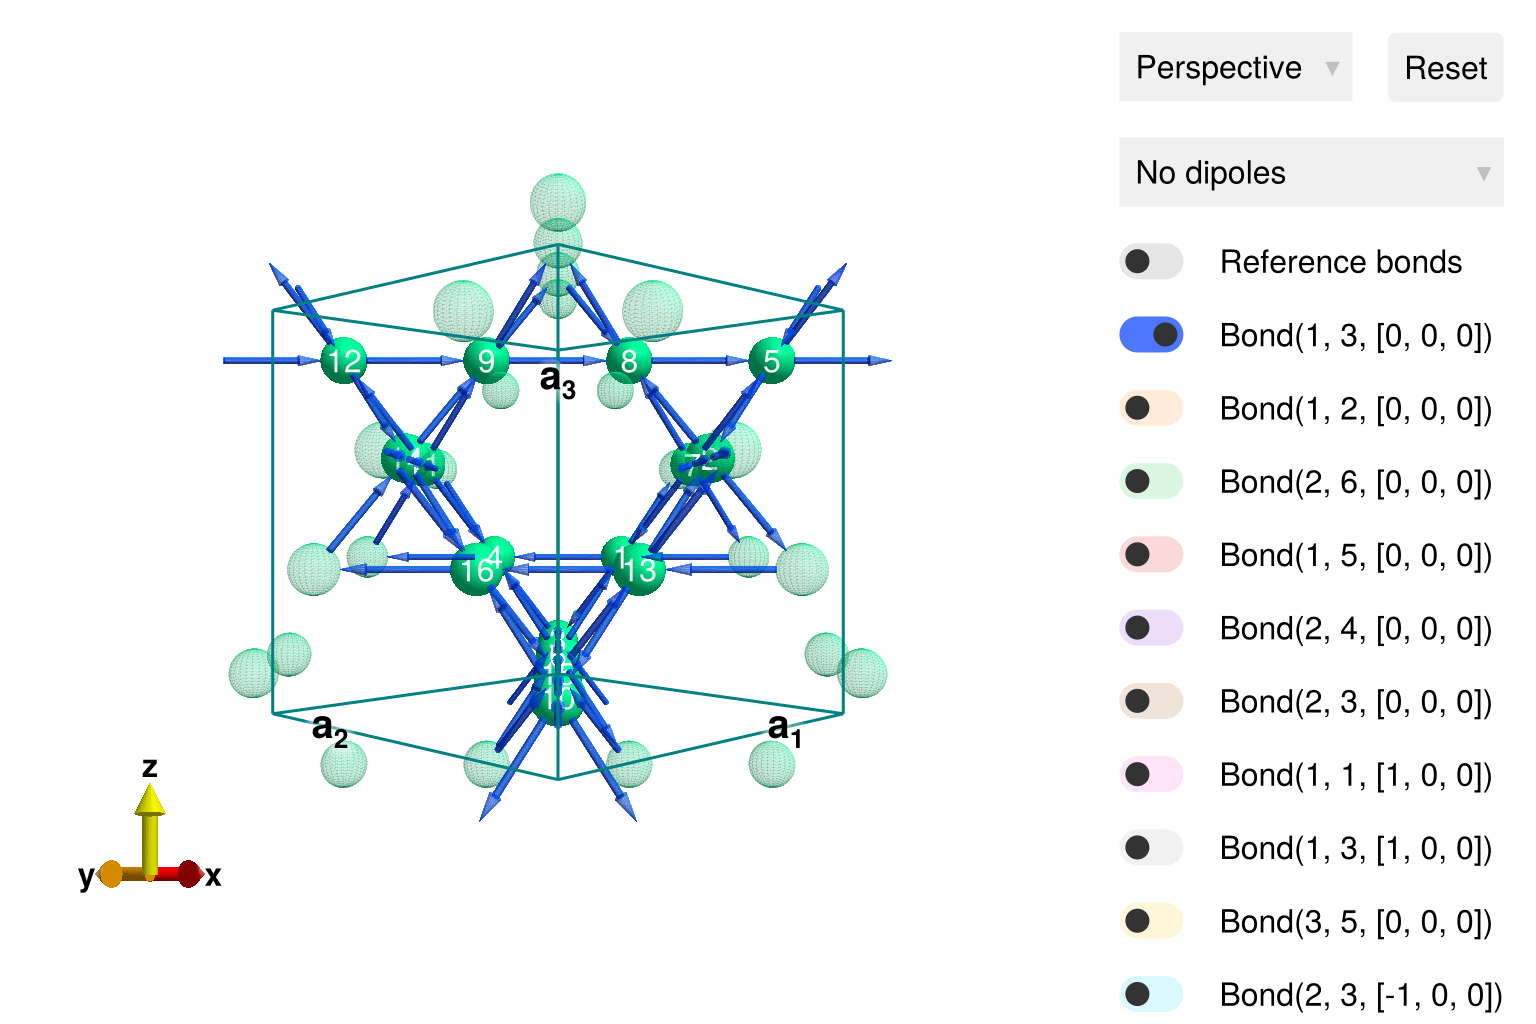

In [58]:
view_crystal(sys)

In [59]:
J_nn = 1.8 * 11.604
set_exchange!(sys, J_nn, Bond(1, 3, [0,0,0]))

sys_extend = reshape_supercell(sys, [10 0 0; 0 10 0; 0 0 10])
randomize_spins!(sys_extend)
minimize_energy!(sys_extend, maxiters=10000)

display(energy_per_site(sys_extend))

-334.19519999999994

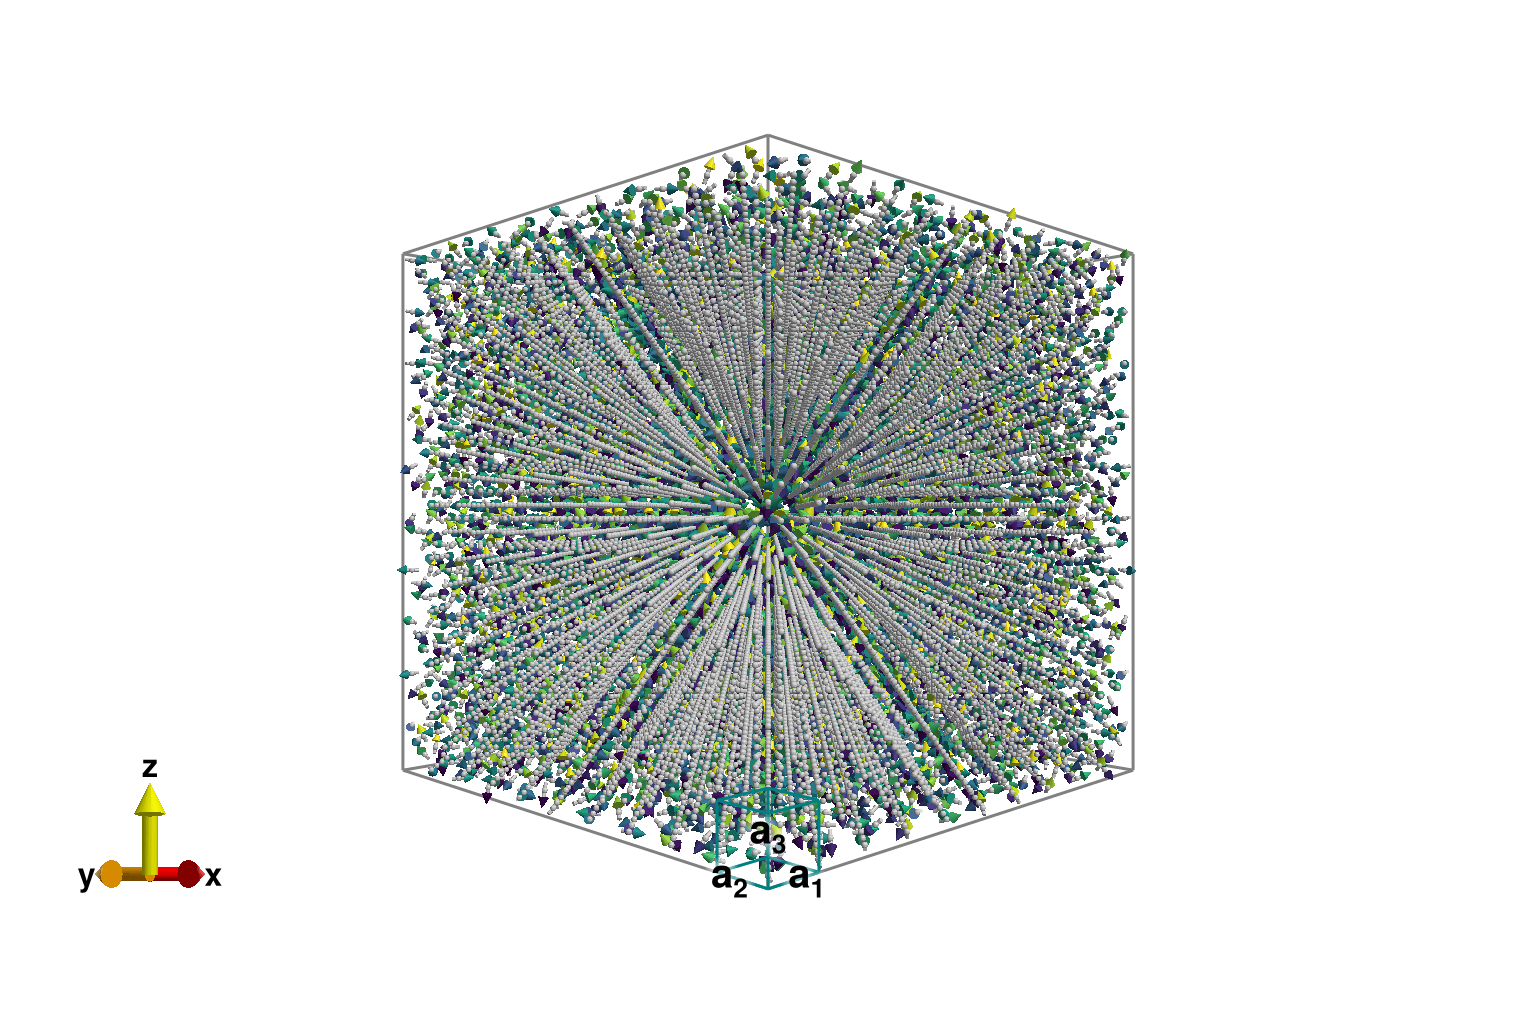

In [25]:
plot_spins(sys_extend; color=[S[3] for S in sys_extend.dipoles])

In [21]:
print_wrapped_intensities(sys_extend, nmax=20)

Dominant wavevectors for spin sublattices:

    [1/4, 1/4, 0]           2.43% weight
    [-1/4, -1/4, 0]         2.43%
    [1/2, -1/4, 1/4]        2.23%
    [1/2, 1/4, -1/4]        2.23%
    [0, 1/4, 0]             2.23%
    [0, -1/4, 0]            2.23%
    [0, 1/2, 1/2]           1.99%
    [1/4, 0, 1/2]           1.86%
    [-1/4, 0, 1/2]          1.86%
    [-1/4, 1/4, 1/4]        1.85%
    [1/4, -1/4, -1/4]       1.85%
    [0, 0, 1/4]             1.75%
    [0, 0, -1/4]            1.75%
    [1/4, 1/2, 0]           1.74%
    [-1/4, 1/2, 0]          1.74%
    [1/4, 1/4, 1/4]         1.71%
    [-1/4, -1/4, -1/4]      1.71%
    [1/4, -1/4, 1/4]        1.71%
    [-1/4, 1/4, -1/4]       1.71%
    [0, 1/2, 1/4]           1.67%
    [0, 1/2, -1/4]          1.67%
    ...                      ...


### Langevin

Consider dt ≈ 0.0001447 for this spin configuration at tol = 0.001000. Current value is dt = 0.0001000.


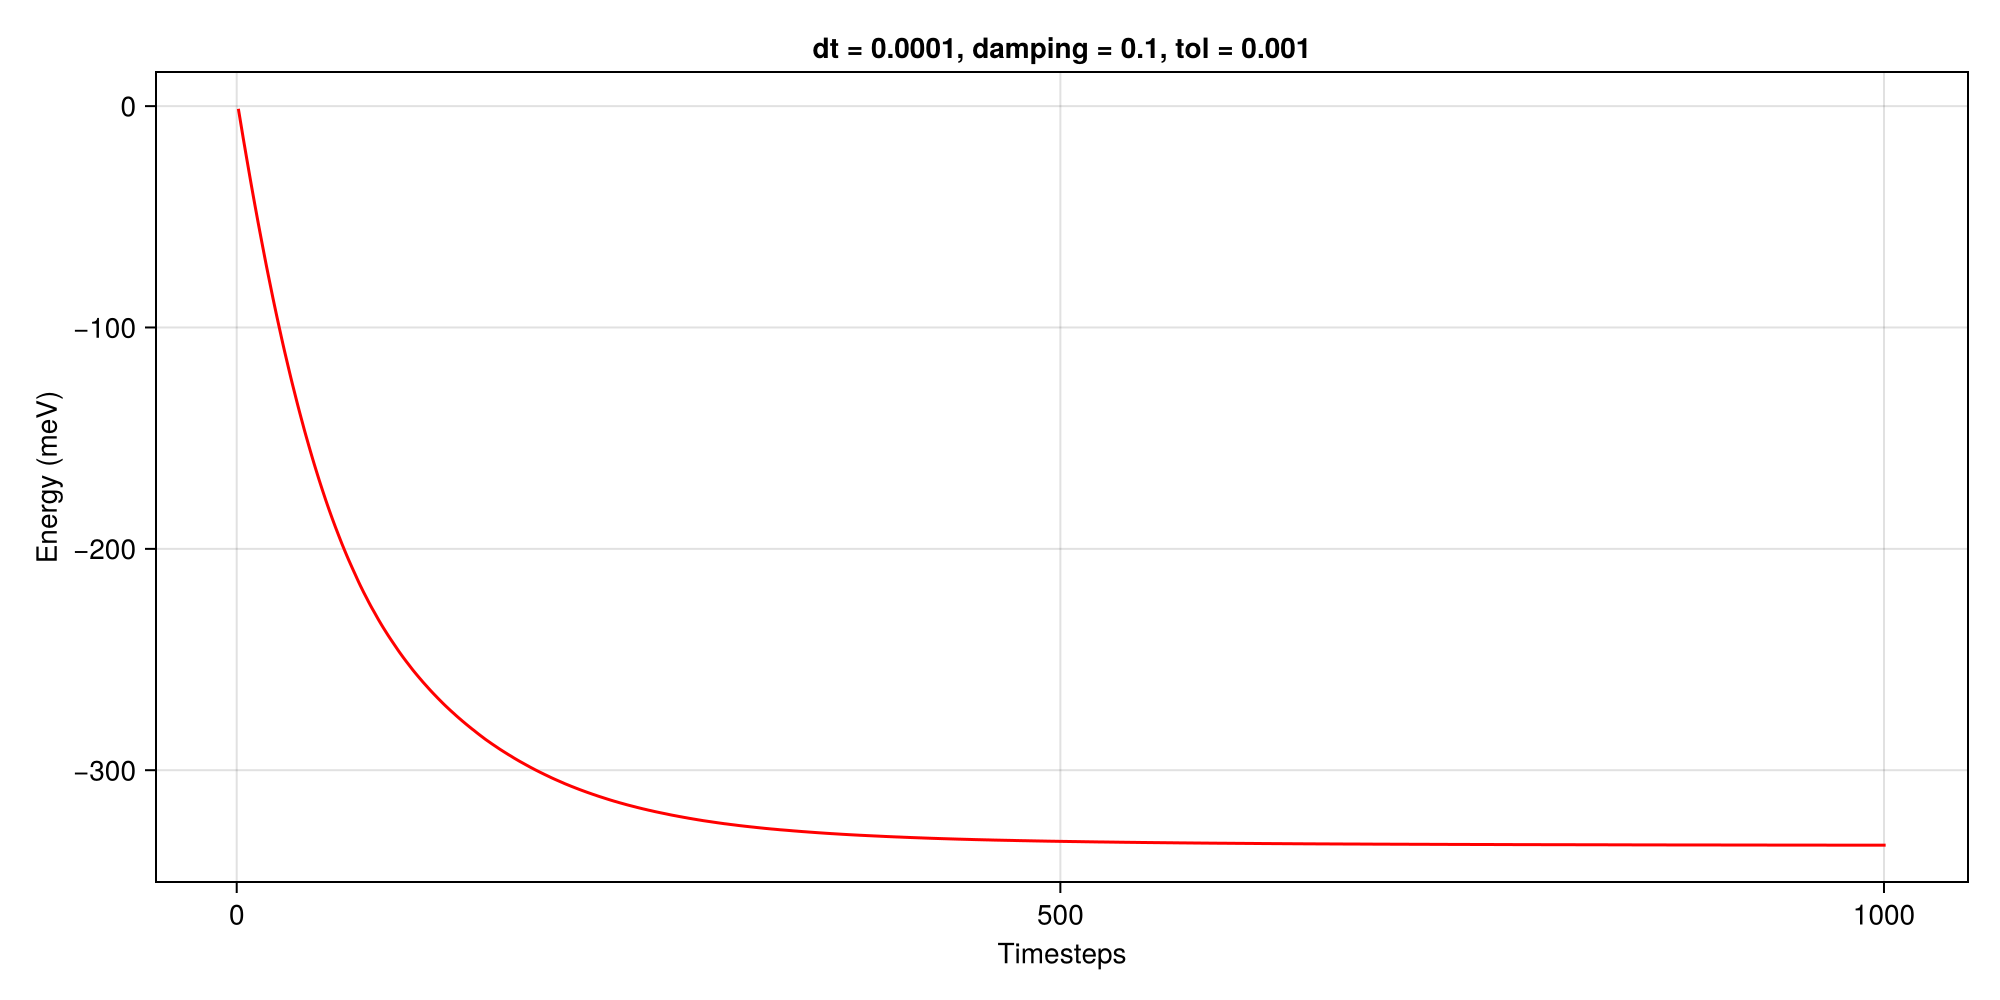

In [96]:
kT      = 1.7 / 11            
tol     = 1e-3                 
nsteps  = 1000

dt      = 1e-4    
damping = 0.1     
kT      = 1.7/11


sys_i = reshape_supercell(sys, [4 0 0; 0 4 0; 0 0 4]) 
randomize_spins!(sys_i)

fig2 = Figure(size=(1000, 500))

langevin = Langevin(dt; damping, kT)
suggest_timestep(sys_i, langevin; tol=tol)

energies = [energy_per_site(sys_i)]
for _ in 1:nsteps
    step!(sys_i, langevin)
    push!(energies, energy_per_site(sys_i))
end
ax = Axis(fig2[1,1];
    xlabel = "Timesteps",
    ylabel = "Energy (meV)",
    title  = "dt = $(dt), damping = $(damping), tol = $(tol)")
lines!(ax, energies, color=:red)


fig2


In [144]:
#Sample
kT      = 1.7*Sunny.meV_per_K
dt      = 1e-4
damping = 0.1
si=3 # q-space pixel size as 1/si

langevin = Langevin(dt; damping, kT)

# Energy range: max resolvable frequency ~ π/dt, but stay physically reasonable

energies = range(0, 5, 100)

formfactors = [1 => FormFactor("Ho3")]
sys_i = reshape_supercell(sys, [si 0 0; 0 si 0; 0 0 si]) 
randomize_spins!(sys_i)

sc = SampledCorrelations(sys_i; dt, energies, measure=ssf_perp(sys_i; formfactors))

n_decorr  = 600   # steps between samples (matching thermalization)
n_samples = 35     # more samples = smoother spectrum

@showprogress for sample in 1:n_samples #for sample in 1:n_samples
    for _ in 1:n_decorr
        step!(sys_i, langevin)
    end
    add_sample!(sc, sys_i)
end

Progress: 100%|█████████████████████████████████████████| Time: 0:45:31


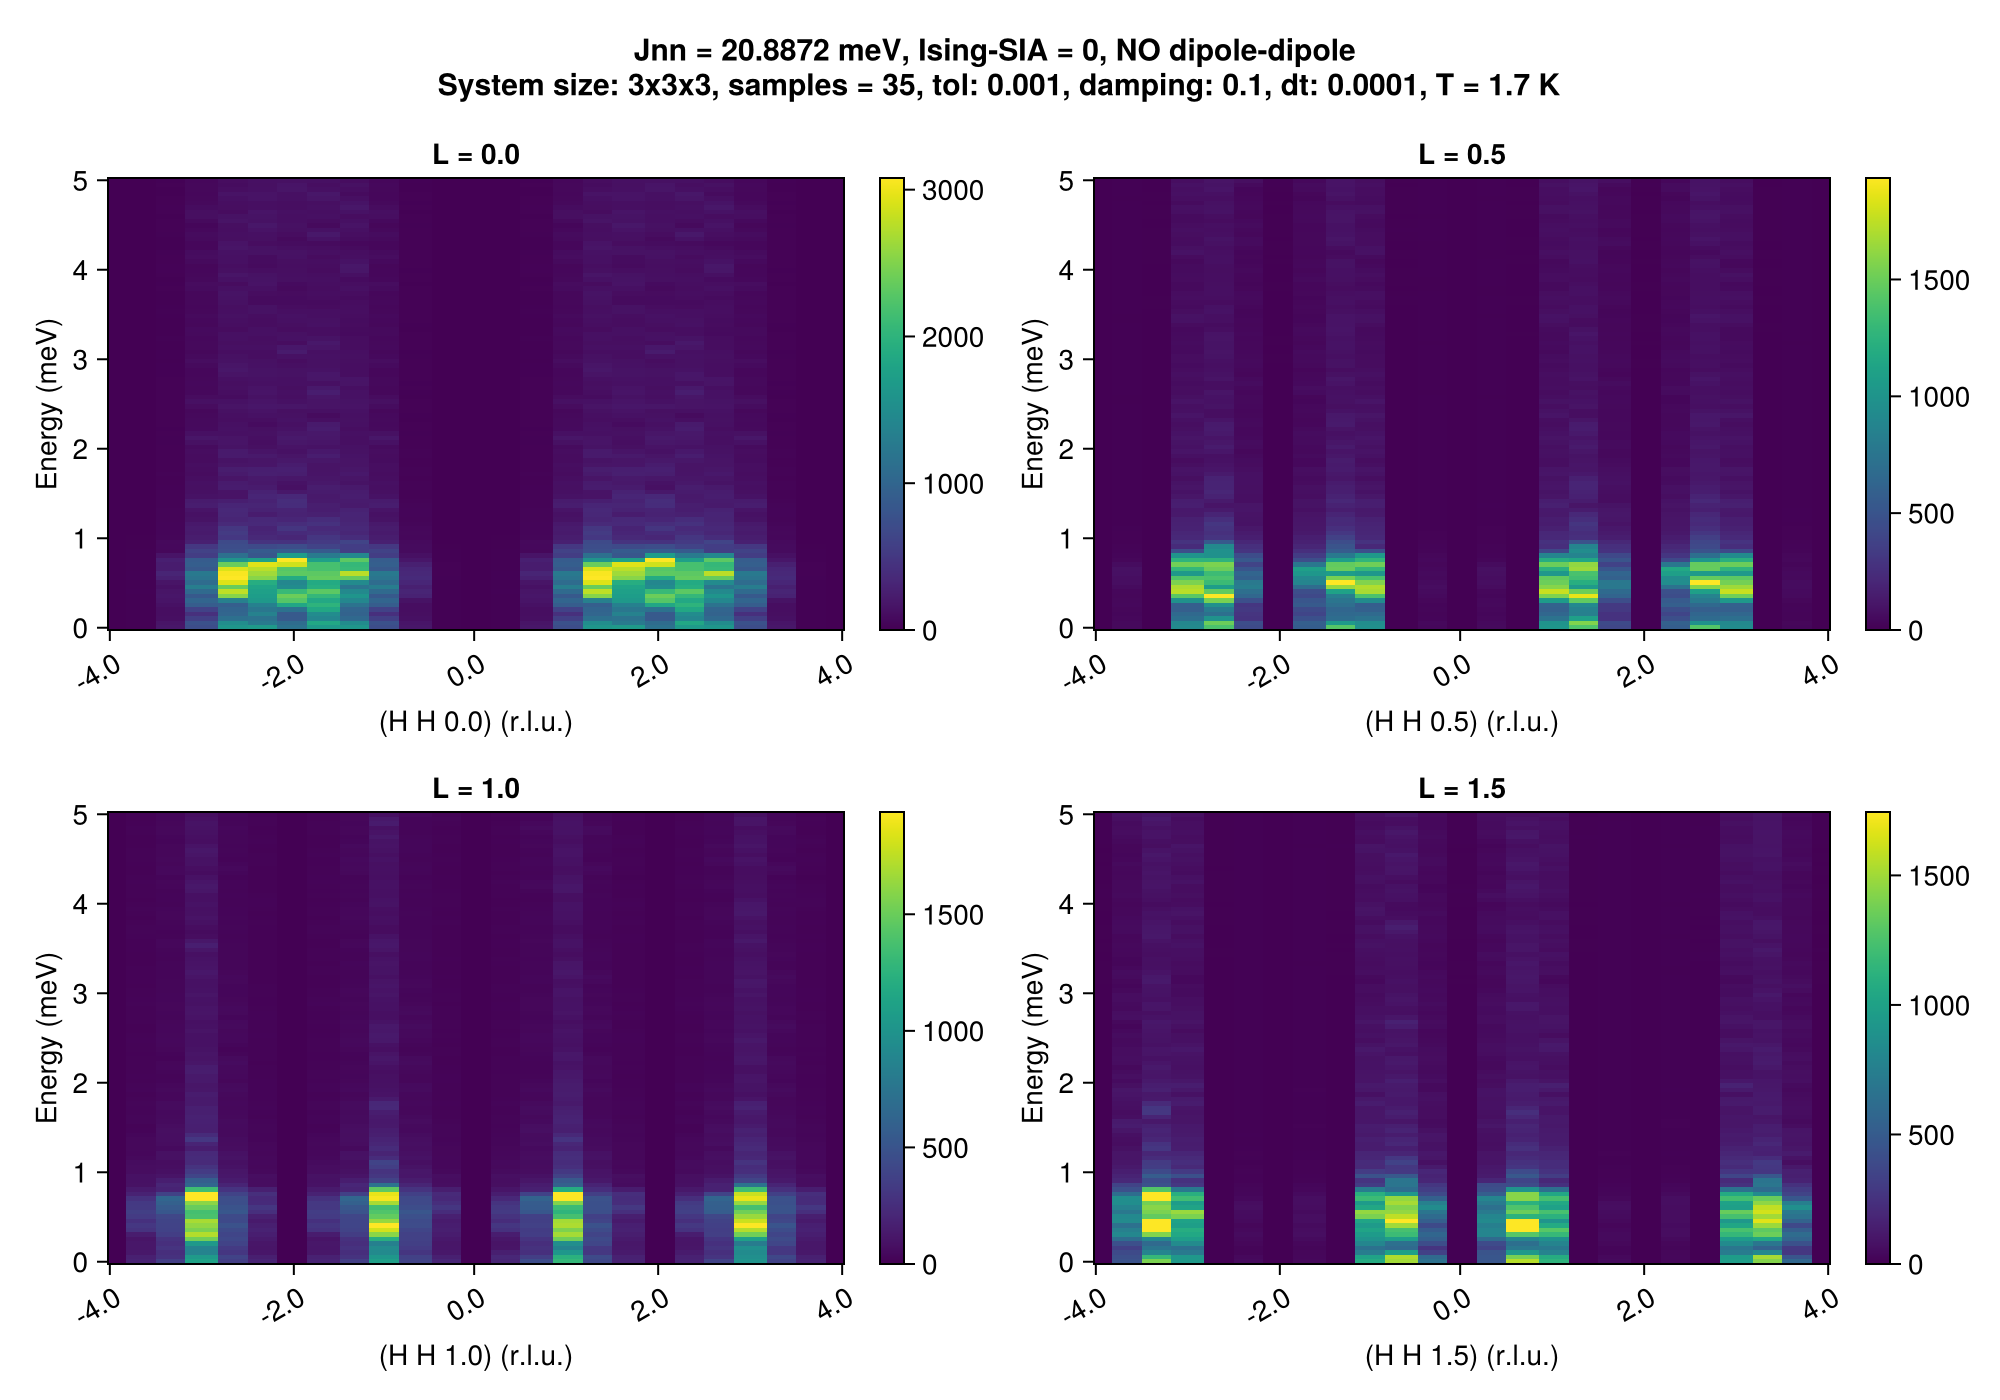

In [152]:
#Plot (Q,E)-colormap (energies are chosen, q's aren't yet)
fig = Figure(size=(800, 600))
qbs = 0.0


qbs  = 0.0:0.5:1.5
dirs = ["h", "h", "h", "h"]  # adjust per slice
npts = 200

fig = Figure(size=(1000, 700))

for (i, qb) in enumerate(qbs)
    path = [[-4, -4, qb], [4, 4, qb]]
    qpts = q_space_path(cryst, path, npts)
    Sqw  = intensities(sc, qpts; energies=:available, kT)

    xticks, xlabels = qticks_lang(5, path, npts, dirs[i])
    emax = energies[end]

    plot_intensities!(fig[fldmod1(i, 2)...], Sqw;
        title = "L = $qb",
        colormap = :viridis,
        axis = (
            yticks      = 0:emax/emax:emax,
            xticks      = (xticks, xlabels),
            xlabel      = "(H H $(qb)) (r.l.u.)",
            ylabel      = "Energy (meV)",
        )
    )
end

Label(fig[0, 1:2], "Jnn = $(J_nn) meV, Ising-SIA = 0, NO dipole-dipole \nSystem size: $(si)x$(si)x$(si), samples = $(n_samples), tol: $(tol), damping: $(damping), dt: $(dt), T = $(kT/Sunny.meV_per_K) K"; fontsize=15, font=:bold)

fig

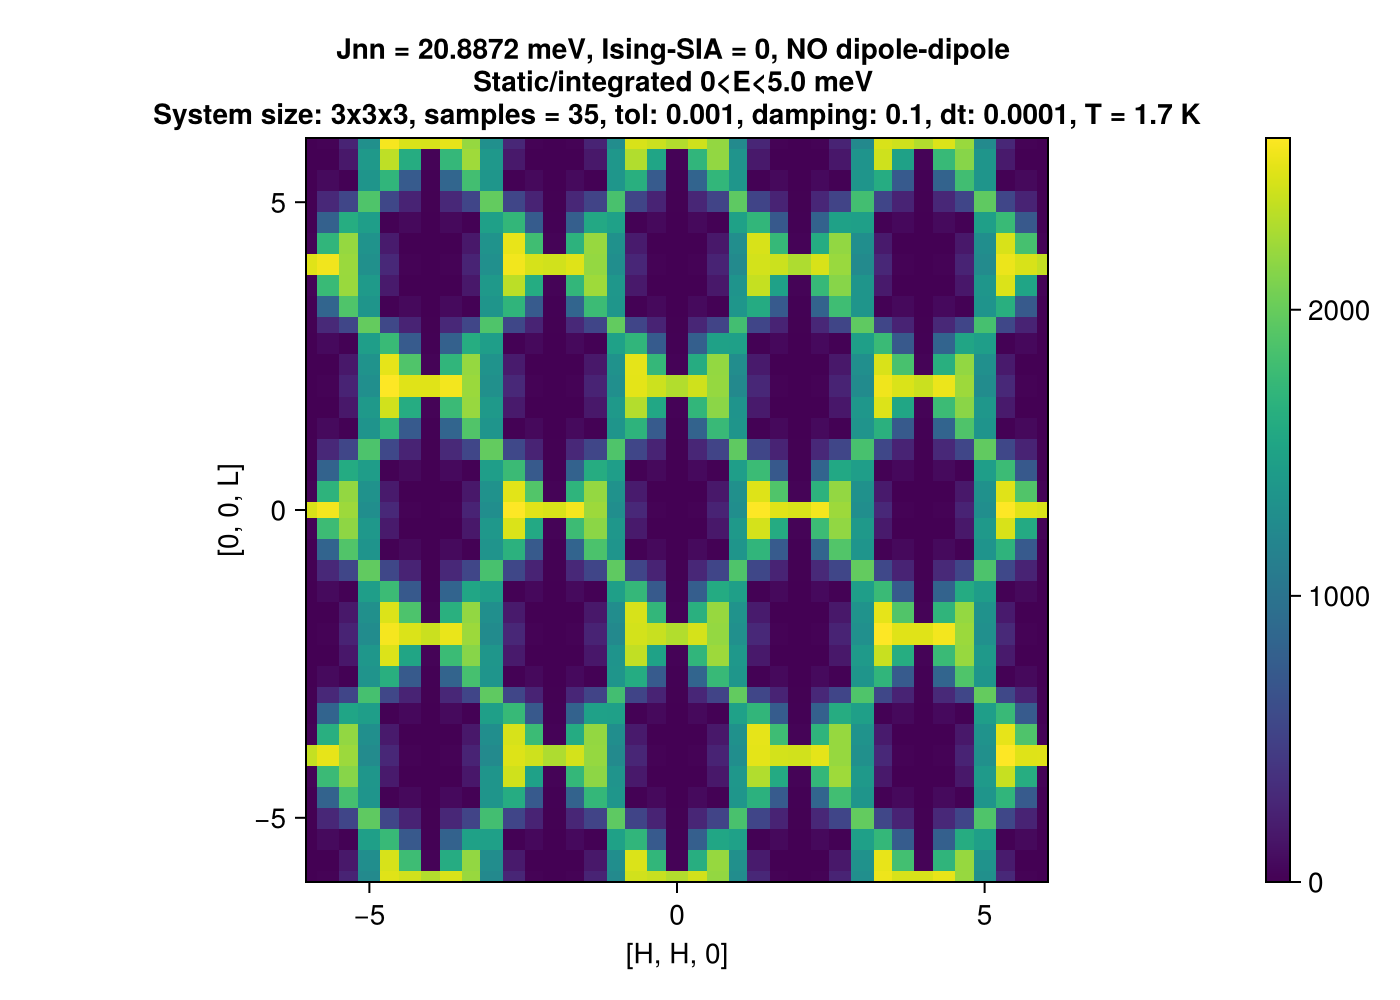

In [151]:
#Plot integrated over all E (Q,Q)-cut (Static intensities)
qpts = q_space_grid(cryst, [1, 1, 0], range(-6, 6, 200), [0, 0, 1], (-6, 6))
Sq  = intensities_static(sc, qpts; kT)


fig = Figure(; size=(700,500))
plot_intensities!(fig[1,1], Sq; title="Jnn = $(J_nn) meV, Ising-SIA = 0, NO dipole-dipole \nStatic/integrated 0<E<$(energies[end]) meV \nSystem size: $(si)x$(si)x$(si), samples = $(n_samples), tol: $(tol), damping: $(damping), dt: $(dt), T = $(round(kT/Sunny.meV_per_K; digits=3)) K", 
    colormap=:viridis)
ax = current_axis()
ax.aspect = DataAspect()
fig